# Simpsons Characters: Stochastic Attention Experiment
In this experiment we explore generation of natural face images at scale using the stochastic attention model. We encode $K = 100$ grayscale Simpsons character images at $64 \times 64$ resolution ($d = 4{,}096$) into the modern Hopfield energy and run the Langevin-based sampler to generate novel character images.

> __Learning Objectives__
>
> By the end of this experiment, you should be able to:
>
> * **Scale the stochastic attention model to natural images**: Apply the SA framework to 4096-dimensional patterns (5.2x larger than MNIST), demonstrating that the Langevin-based sampler works beyond simple digit images.
> * **Understand inverse temperature as an order parameter**: Observe how the inverse temperature drives a transition from disordered noise to structured character retrieval, with a critical threshold for this dataset.
> * **Compare SA against baselines on natural images**: Evaluate novelty, diversity, and Hopfield energy across five methods (SA, MALA, Gaussian perturbation, random convex combination, bootstrap) on the Simpsons character dataset.

Let's get started!
___

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Apply stochastic attention to natural images:__ Run the sampler on 64x64 color images of Simpsons characters and generate novel face images that blend features from the memory bank
> * __Evaluate generation quality at scale:__ Compute novelty, diversity, and energy metrics on high-dimensional image data (4096 dimensions) and compare against the same four baselines used in the MNIST experiment
> * __Understand the inverse-temperature spectrum:__ Visualize how varying the inverse temperature from noise through generation to retrieval manifests on natural face images

Let's get started!
___

## Background: The Modern Hopfield Energy and the SNR Scaling Rule

The modern Hopfield energy for a state $\boldsymbol{\xi} \in \mathbb{R}^d$ given a memory matrix $\mathbf{X} \in \mathbb{R}^{d \times K}$ is:
$$
E(\boldsymbol{\xi}) = \tfrac{1}{2}\|\boldsymbol{\xi}\|_{2}^2 - \tfrac{1}{\beta}\log\sum_{k=1}^{K}\exp(\beta\,\mathbf{m}_k^\top\boldsymbol{\xi})
$$
The stochastic attention sampler (Algorithm 1) runs Unadjusted Langevin Dynamics on this energy:
$$
\boldsymbol{\xi}_{t+1} = (1-\alpha)\,\boldsymbol{\xi}_t + \alpha\,\mathbf{X}\,\operatorname{softmax}(\beta\,\mathbf{X}^\top\boldsymbol{\xi}_t) + \sqrt{2\alpha/\beta}\;\boldsymbol{\epsilon}_t, \qquad \boldsymbol{\epsilon}_t \sim \mathcal{N}(\mathbf{0}, \mathbf{I})
$$

> **Choosing $\beta$: the per-step SNR argument**
>
> At each step, the gradient term pulls the state toward the memory manifold with magnitude $O(\alpha)$, while the injected noise has expected $\ell_2$ norm $\sqrt{2\alpha/\beta}\,\mathbb{E}[\|\mathbf{z}\|_{2}] \approx \sqrt{2\alpha d/\beta}$ for $\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I}_d)$. The per-step signal-to-noise ratio (Eq.~SNR in the paper) is therefore:
> $$
> \mathrm{SNR} = \frac{\alpha}{\sqrt{2\alpha d/\beta}} = \sqrt{\frac{\alpha\beta}{2d}}
> $$
> **This scales as $\sqrt{\beta/d}$, so $\beta$ must grow linearly with $d$ to hold the operating point fixed.**
>
> For MNIST ($d = 784$) the paper used $\beta = 2{,}000$, giving $\mathrm{SNR} = \sqrt{0.01 \times 2000 / (2 \times 784)} \approx 0.113$. Matching this SNR at $d = 4{,}096$ requires:
> $$
> \beta_{\text{Simpsons}} = \mathrm{SNR}^2 \times \frac{2d}{\alpha} = 0.01276 \times \frac{2 \times 4096}{0.01} \approx 10{,}449
> $$
> We use $\beta = 10{,}000$ (SNR $\approx 0.110$), operating in the same structured-generation regime as the MNIST experiment.
>
> The $\beta$ sweep uses values that span SNR $\approx 0.025$ (disordered) to SNR $\approx 0.156$ (deeply ordered): $\{500,\,1000,\,2000,\,5000,\,10000,\,20000\}$.

___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include-Simpsons.jl` file and loading any needed resources.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include-Simpsons.jl`, in the notebook's global scope. The `Include-Simpsons.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include-Simpsons.jl")); # include the Include-Simpsons.jl file

### Helper Implementations

In [2]:
# helper: get file extension
file_extension(file::String) = file[findlast(==('.'), file)+1:end];

# helper: reshape a flattened state vector back to a displayable image matrix.
# Pixels were stored row-major (row ∈ 1:rows, col ∈ 1:cols), so reshape then transpose.
function decode(s::Vector{<:Number}; number_of_rows::Int=64, number_of_cols::Int=64)::Array{<:Number,2}
    X = reshape(s, number_of_rows, number_of_cols) |> X -> transpose(X) |> Matrix;
    X̂ = replace(X, -1 => 0);
    return X̂
end;

### Constants
We define constants that control image dimensions, the memory bank size, sampler hyperparameters, and the $\beta$ sweep. The main inverse temperature $\beta_{\text{main}}$ is set via the SNR scaling rule derived in the Background section.

In [3]:
# --- image dimensions ---
number_of_rows = 64;           # downscaled image height (pixels)
number_of_cols = 64;           # downscaled image width  (pixels)
number_of_pixels = number_of_rows * number_of_cols;  # d = 4096

# --- memory bank ---
K = 100;                       # number of stored patterns (same as MNIST for direct comparison)
                               # load ratio = K/d = 100/4096 ≈ 0.024, well below capacity

# --- sampler hyperparameters ---
α  = 0.01;                     # step size — same as MNIST (small to control ULA discretization bias)

# β is set by the SNR scaling rule: SNR = √(αβ/2d) = √(β/819200) for α=0.01, d=4096.
# MNIST used β=2000 at d=784 → SNR_MNIST = √(0.01×2000/(2×784)) ≈ 0.113.
# To match SNR at d=4096: β = SNR² × 2d/α = 0.01276 × 819200 ≈ 10,449. We use β = 10,000.
SNR_MNIST   = sqrt(0.01 * 2000 / (2 * 784));        # ≈ 0.113  (MNIST operating point)
β_main      = round(SNR_MNIST^2 * 2 * number_of_pixels / α / 1000) * 1000 |> Float64; # ≈ 10000.0
SNR_main    = sqrt(α * β_main / (2 * number_of_pixels));

S  = 150;                      # total samples to collect per method

# --- multi-chain configuration (same as MNIST) ---
n_chains           = 30;       # independent chains (each seeds a different energy basin)
T_per_chain        = 5000;     # iterations per chain
T_burnin_per_chain = 2000;     # burn-in iterations discarded per chain
thin_interval      = 100;      # keep every 100th post-burn-in sample
samples_per_chain  = 5;        # samples kept per chain → 30 × 5 = 150 total

# --- β sweep for the SNR/order-parameter section ---
# Values chosen to span SNR ≈ 0.025 (disordered) to SNR ≈ 0.156 (deeply ordered),
# bracketing the operating point SNR ≈ 0.110 at β=10,000.
β_sweep     = [500.0, 1000.0, 2000.0, 5000.0, 10000.0, 20000.0];
T_sweep     = 2000;            # chain length for β-sweep visualization
T_burnin_sweep = 500;          # burn-in for β-sweep chains

println("d = $(number_of_pixels), K = $(K), α = $(α)")
println("SNR_MNIST  = $(round(SNR_MNIST,  digits=4))  (MNIST operating point, d=784, β=2000)")
println("β_main     = $(β_main)   (SNR = $(round(SNR_main, digits=4))  ≈ SNR_MNIST ✓)")
println("Noise scale σ = $(round(sqrt(2*α/β_main), digits=6))")
println("β sweep SNRs: $(round.(sqrt.(α .* β_sweep ./ (2*number_of_pixels)), digits=3))")

d = 4096, K = 100, α = 0.01
SNR_MNIST  = 0.1129  (MNIST operating point, d=784, β=2000)
β_main     = 10000.0   (SNR = 0.1105  ≈ SNR_MNIST ✓)
Noise scale σ = 0.001414
β sweep SNRs: [0.025, 0.035, 0.049, 0.078, 0.11, 0.156]


### Load and Preprocess Images
We load all 1000 Simpsons character images from the `images/` directory, convert them to grayscale, and **downscale from 200×200 to 64×64** using bilinear interpolation. The downscaled images are stored as `Float64` vectors of length $d = 4{,}096$.

> **Why downscale?** The original 200×200 images give $d = 40{,}000$. While physically storing the memory matrix poses no problem ($\mathbf{X} \in \mathbb{R}^{40000 \times 100}$ is only ~32 MB), each Langevin step requires two matrix–vector products of cost $O(dK)$. At $d=40{,}000$ with 30 chains × 5,000 steps, total work exceeds 10 hours. Downscaling to $d = 4{,}096$ reduces compute ~10× while preserving enough spatial detail for recognizable characters.

In [4]:
training_image_dictionary = let
    training_image_dictionary = Dict{Int64, Array{Gray{Float64},2}}();
    files = readdir(_PATH_TO_IMAGES);
    imagecount = 1;
    for filename in files
        ext = file_extension(filename)
        if ext == "png"
            raw = FileIO.load(joinpath(_PATH_TO_IMAGES, filename)) |> img -> Gray.(img);
            resized = imresize(raw, number_of_rows, number_of_cols); # downscale to 64×64
            training_image_dictionary[imagecount] = Float64.(resized);
            imagecount += 1
        end
    end
    println("Loaded $(length(training_image_dictionary)) images at $(number_of_rows)×$(number_of_cols)")
    training_image_dictionary
end;

Loaded 1000 images at 64×64


Let's view a sample image to confirm the downscaling looks reasonable:

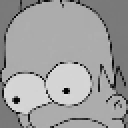

In [5]:
Gray.(training_image_dictionary[42]) # show example image at 64×64 resolution

### Select K Patterns and Build Memory Matrices
We randomly select $K = 100$ images to form the memory bank, then build:
- **`X`**: unnormalized memory matrix — each column is a row-major-linearized $64 \times 64$ grayscale image in $[0,1]^{4096}$.
- **`X̂`**: unit-norm memory matrix — each column of `X` divided by its $\ell_2$ norm. Unit normalization places all patterns on the unit sphere $\mathbb{S}^{d-1}$, which is required for the Hopfield energy and sampler to operate on a consistent scale (same convention as MNIST Experiment-4).

In [6]:
# Select K random image indices (fixed seed for reproducibility)
Random.seed!(42)
N_total = length(training_image_dictionary);
pattern_indices = StatsBase.sample(1:N_total, K, replace=false) |> sort;
println("Selected pattern indices (first 10): $(pattern_indices[1:10])")

Selected pattern indices (first 10): [37, 63, 64, 66, 99, 100, 104, 112, 129, 133]


In [7]:
X, X̂ = let
    ϵ = 1e-12; # small number to avoid division by zero
    X  = zeros(Float64, number_of_pixels, K); # unnormalized memory matrix
    X̂  = zeros(Float64, number_of_pixels, K); # unit-norm memory matrix

    for (col, idx) in enumerate(pattern_indices)
        img = training_image_dictionary[idx]; # 64×64 Float64 matrix
        # row-major linearization: row ∈ 1:rows, col ∈ 1:cols
        xᵢ = vec(reshape(transpose(img) |> Matrix, number_of_pixels));
        X[:, col]  = xᵢ;
        X̂[:, col]  = xᵢ ./ (norm(xᵢ) + ϵ); # normalize to unit norm
    end

    (X, X̂)
end;

println("X:  $(size(X))   (unnormalized memory matrix)")
println("X̂:  $(size(X̂))   (unit-norm memory matrix)")

X:  (4096, 100)   (unnormalized memory matrix)
X̂:  (4096, 100)   (unit-norm memory matrix)


__Check:__ Decode a column of `X̂` back to image format — it should look like a recognizable (though faint, since unit-norm vectors have tiny pixel values) Simpson character.

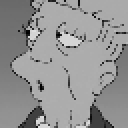

In [8]:
let
    col = 1;
    img = decode(X[:, col]);          # decode unnormalized version for better contrast
    Gray.(img)
end

In [9]:
let
    ϵ = 1e-6;
    col_to_check = 1;
    l = norm(X̂[:, col_to_check]);
    @assert isapprox(l, 1.0, atol = ϵ) "Expected unit norm, got $l"
    println("‖X̂[:,1]‖ = $(round(l, digits=12))  ✓")
end

‖X̂[:,1]‖ = 1.0  ✓


___

## Section 1: β Spectrum — From Noise to Retrieval

Before running the full multi-chain comparison, we visualize the effect of $\beta$ on the generated images through the lens of the SNR scaling rule. For each $\beta \in \{500, 1000, 2000, 5000, 10000, 20000\}$ we run a single SA chain initialized near the first stored pattern and show 4 thinned samples.

The corresponding SNR values are:

| $\beta$ | SNR $= \sqrt{\alpha\beta/(2d)}$ | Regime |
|---|---|---|
| 500 | 0.025 | Disordered — noise dominates gradient |
| 1000 | 0.035 | Near transition |
| 2000 | 0.049 | Weakly ordered |
| 5000 | 0.078 | Ordered, some basin mixing |
| **10,000** | **0.110** | **Operating point (matches MNIST SNR)** |
| 20,000 | 0.156 | Deeply ordered — sharp retrieval |

> **What to expect:** Top rows (low SNR) show diffuse, noisy images. The bottom rows (high SNR) show recognizable Simpson characters. The transition in image quality tracks the SNR, not an absolute $\beta$ value — illustrating why $\beta$ must scale with $d$.

This panel serves as the temperature-spectrum figure for the paper appendix.

In [10]:
beta_spectrum_samples = let
    σ_init = 0.01
    n_show = 4   # one independent chain per column, initialized from faces 1..n_show
    results = Dict{Float64, Vector{Vector{Float64}}}()

    for β_val in β_sweep
        cols = Vector{Vector{Float64}}()
        for col in 1:n_show
            Random.seed!(2025 + col)
            sₒ = X̂[:, col] .+ σ_init .* randn(number_of_pixels)
            (t, Ξ) = sample(X̂, sₒ, T_sweep; β = β_val, α = α, seed = 2025 + col)
            push!(cols, Ξ[end, :])   # endpoint after T_sweep steps
        end
        results[β_val] = cols
    end
    println("β spectrum chains complete.")
    results
end;

β spectrum chains complete.


Saved Fig_simpsons_beta_spectrum.png


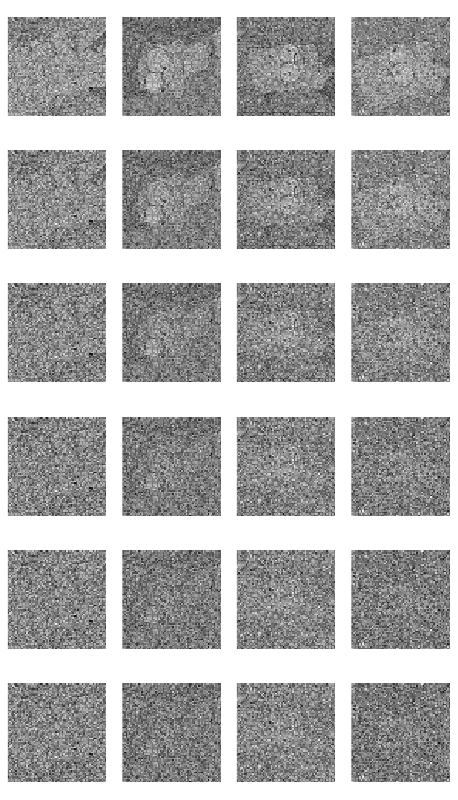

In [11]:
let
    gr()
    β_sorted = sort(β_sweep, rev = true)

    all_plts = Plots.Plot[]

    for β_val in β_sorted
        samples = beta_spectrum_samples[β_val]

        # ── four image subplots ──────────────────────────────────────────────
        for s in samples
            img = decode(s)
            lo, hi = minimum(img), maximum(img)
            hi > lo && (img = (img .- lo) ./ (hi - lo))
            p = heatmap(img';
                color        = :grays,
                aspect_ratio = :equal,
                framestyle   = :none,
                ticks        = nothing,
                colorbar     = false,
                yflip        = true,
                margin       = 0Plots.mm)
            push!(all_plts, p)
        end
    end

    # 6 rows × 4 cols: plain image grid
    l = @layout [
        a b c d
        e f g h
        i j k l
        m n o p
        q r s t
        u v w x
    ]

    fig = plot(all_plts..., layout = l, size = (460, 800))
    savefig(fig, joinpath(_PATH_TO_FIG, "Fig_simpsons_beta_spectrum.png"))
    println("Saved Fig_simpsons_beta_spectrum.png")
    fig
end

___

## Case 1: Stochastic Attention Model (Multi-Chain, $\beta = 10{,}000$)

At our operating point $\beta = 10{,}000$ (SNR $\approx 0.110$, matching the MNIST experiment), a single chain quickly converges to one energy basin and stays there. This is correct MCMC behavior for a concentrated distribution, but a single chain lacks diversity across basins.

**Solution: multiple independent chains.** We launch `n_chains = 30` independent chains, each initialized near a different stored pattern with small Gaussian noise ($\sigma_{\text{init}} = 0.01$). Each chain runs for `T_per_chain = 5000` iterations, and we collect `samples_per_chain = 5` thinned post-burn-in samples. Because different initializations land in different energy basins, pooling recovers basin diversity — the same multi-chain protocol used in the MNIST experiment.

In [12]:
chain_trajectories = let
    σ_init = 0.01;
    trajectories = Vector{Matrix{Float64}}();

    Random.seed!(42)
    seed_patterns = StatsBase.sample(1:K, n_chains, replace = (n_chains > K));

    for (c, k) in enumerate(seed_patterns)
        Random.seed!(12345 + c)
        sₒ = X̂[:, k] .+ σ_init .* randn(number_of_pixels);
        (t, Ξ) = sample(X̂, sₒ, T_per_chain; β = β_main, α = α, seed = 12345 + c);
        push!(trajectories, Ξ);
    end
    println("Ran $(n_chains) SA chains at β=$(β_main)")
    trajectories
end;

Ran 30 SA chains at β=10000.0


In [13]:
sa_generated_images_vector = let
    generated_images_vector = Vector{Vector{Float64}}();
    start_index = T_burnin_per_chain + 1;
    stop_index  = T_per_chain;

    for Ξ in chain_trajectories
        chain_samples = [Ξ[tᵢ, :] for tᵢ ∈ start_index:thin_interval:stop_index];
        n_avail = length(chain_samples);
        idx = round.(Int, range(1, n_avail, length = min(samples_per_chain, n_avail)));
        for i in idx; push!(generated_images_vector, chain_samples[i]); end
    end
    println("Collected $(length(generated_images_vector)) SA samples from $(n_chains) chains")
    generated_images_vector
end;

Collected 150 SA samples from 30 chains


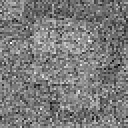

In [14]:
let
    random_index = rand(1:length(sa_generated_images_vector));
    img = decode(sa_generated_images_vector[random_index]);
    lo, hi = minimum(img), maximum(img);
    if hi > lo; img = (img .- lo) ./ (hi - lo); end
    Gray.(img)
end

___
## Case 1b: MALA Baseline (Multi-Chain, $\beta = 10{,}000$)

MALA uses the same Langevin proposal as the SA sampler but adds a Metropolis–Hastings accept/reject correction to eliminate ULA's discretization bias. This makes MALA asymptotically exact for any step size $\alpha$, whereas ULA converges to the true Boltzmann distribution only as $\alpha \to 0$.

We run the same multi-chain protocol: same $\beta = 10{,}000$, $\alpha$, burn-in, thinning, and initial seeds. The only difference is the accept/reject step. If ULA's discretization bias is small (as expected for small $\alpha = 0.01$), SA and MALA should yield similar results.

In [15]:
mala_chain_trajectories, mala_accept_rates = let
    σ_init = 0.01;
    trajectories  = Vector{Matrix{Float64}}();
    accept_rates  = Float64[];

    Random.seed!(42)
    seed_patterns = StatsBase.sample(1:K, n_chains, replace = (n_chains > K));

    for (c, k) in enumerate(seed_patterns)
        Random.seed!(12345 + c)
        sₒ = X̂[:, k] .+ σ_init .* randn(number_of_pixels);
        (t, Ξ, ar) = mala_sample(X̂, sₒ, T_per_chain; β = β_main, α = α, seed = 12345 + c);
        push!(trajectories, Ξ);
        push!(accept_rates, ar);
    end
    println("Ran $(n_chains) MALA chains at β=$(β_main)")
    println("Accept rates: mean=$(round(mean(accept_rates), digits=4)),  min=$(round(minimum(accept_rates), digits=4)),  max=$(round(maximum(accept_rates), digits=4))")
    (trajectories, accept_rates)
end;

Ran 30 MALA chains at β=10000.0
Accept rates: mean=0.9812,  min=0.9784,  max=0.9858


In [16]:
mala_generated_images_vector = let
    generated_images_vector = Vector{Vector{Float64}}();
    start_index = T_burnin_per_chain + 1;
    stop_index  = T_per_chain;

    for Ξ in mala_chain_trajectories
        chain_samples = [Ξ[tᵢ, :] for tᵢ ∈ start_index:thin_interval:stop_index];
        n_avail = length(chain_samples);
        idx = round.(Int, range(1, n_avail, length = min(samples_per_chain, n_avail)));
        for i in idx; push!(generated_images_vector, chain_samples[i]); end
    end
    println("Collected $(length(generated_images_vector)) MALA samples from $(n_chains) chains")
    generated_images_vector
end;

Collected 150 MALA samples from 30 chains


___
## Case 2: Gaussian Perturbation

For each of the $S = 150$ samples we select a stored pattern uniformly at random and add isotropic Gaussian noise $\mathcal{N}(\mathbf{0}, \sigma^2 \mathbf{I})$, where $\sigma = \sqrt{2\alpha/\beta}$ matches the per-step noise scale of Algorithm 1. This baseline isolates the role of gradient-driven drift: any advantage of SA/MALA over Gaussian perturbation is attributable to the Langevin dynamics, not the noise level.

In [17]:
gp_generated_images_vector = let
    generated_images_vector = Vector{Vector{Float64}}();
    σ = sqrt(2 * α / β_main); # noise scale matched to the Langevin sampler

    Random.seed!(12345);
    for _ ∈ 1:S
        k = rand(1:K);
        ξ = X̂[:, k] .+ σ .* randn(number_of_pixels);
        push!(generated_images_vector, ξ);
    end
    generated_images_vector
end;
println("Gaussian perturbation: $(length(gp_generated_images_vector)) samples")

Gaussian perturbation: 150 samples


___
## Case 3: Random Convex Combination

For each sample we draw a weight vector $\mathbf{w} \sim \mathrm{Dirichlet}(1, \ldots, 1)$ — uniform over the $(K{-}1)$-simplex — and compute $\boldsymbol{\xi} = \mathbf{X}\mathbf{w}$. This gives smooth blends of many stored memories, producing blurry outputs that are globally dissimilar to any individual pattern.

In [18]:
rc_generated_images_vector = let
    generated_images_vector = Vector{Vector{Float64}}();
    dirichlet_dist = Dirichlet(K, 1.0);

    Random.seed!(12345);
    for _ ∈ 1:S
        w = rand(dirichlet_dist);
        ξ = X̂ * w;
        push!(generated_images_vector, ξ);
    end
    generated_images_vector
end;
println("Random convex combination: $(length(rc_generated_images_vector)) samples")

Random convex combination: 150 samples


___
## Case 4: Bootstrap Sampling

Bootstrap (replay) sampling draws exact copies of stored patterns. These samples have zero novelty by construction and represent the lower bound for all metrics. Any genuinely generative method should exceed this baseline in novelty and diversity.

In [19]:
bs_generated_images_vector = let
    generated_images_vector = Vector{Vector{Float64}}();

    Random.seed!(12345);
    for _ ∈ 1:S
        k = rand(1:K);
        push!(generated_images_vector, copy(X̂[:, k]));
    end
    generated_images_vector
end;
println("Bootstrap: $(length(bs_generated_images_vector)) samples")

Bootstrap: 150 samples


___

## Quantitative Evaluation

We compute three metrics for all five methods using the unit-norm memory matrix `X̂`:

* **Novelty:** $1 - \max_k \cos(\hat{\boldsymbol{\xi}}, \mathbf{m}_k)$ — how far each sample is from the nearest stored pattern (higher → more novel).
* **Diversity:** mean pairwise cosine distance among generated samples (higher → more spread).
* **Quality (Energy):** mean Hopfield energy $\bar{E}$ (lower → closer to the memory manifold).

These are implemented in `sample_novelty(...)`, `sample_diversity(...)`, and `sample_quality(...)` in `../src/Utilities.jl`.

In [20]:
results_table = let
    methods = [
        "Bootstrap (replay)"        => bs_generated_images_vector,
        "Gaussian perturbation"     => gp_generated_images_vector,
        "Random convex combination" => rc_generated_images_vector,
        "MALA"                      => mala_generated_images_vector,
        "Stochastic attention"      => sa_generated_images_vector,
    ];

    rows = Vector{NamedTuple}();
    for (name, samples) ∈ methods
        novelty   = mean(sample_novelty(ξ, X̂) for ξ in samples);
        diversity = sample_diversity(samples);
        energy    = sample_quality(samples, X̂, β_main);
        push!(rows, (Method = name, Novelty = novelty, Diversity = diversity, Energy = energy));
    end

    df = DataFrame(rows);
    df
end

Row,Method,Novelty,Diversity,Energy
,String,Float64,Float64,Float64
1,Bootstrap (replay),-1.69272e-15,0.117847,-0.5
2,Gaussian perturbation,0.00407184,0.123215,-0.495903
3,Random convex combination,0.0176297,0.00127576,-0.481709
4,MALA,0.157256,0.367931,-0.295888
5,Stochastic attention,0.159419,0.370635,-0.293186


In [21]:
# Per-chain standard errors (SE = std of per-chain metric / √n_chains).
# All methods are grouped into n_chains=30 groups of samples_per_chain=5.
# For SA/MALA the groups correspond to actual chains; for baselines the S=150 samples
# are grouped in the order they were generated (arbitrary but consistent).
se_table = let
    n_per = samples_per_chain;  # 5 samples per group

    rows = Vector{NamedTuple}();
    for (name, samples) ∈ [
            "Bootstrap (replay)"        => bs_generated_images_vector,
            "Gaussian perturbation"     => gp_generated_images_vector,
            "Random convex combination" => rc_generated_images_vector,
            "MALA"                      => mala_generated_images_vector,
            "Stochastic attention"      => sa_generated_images_vector,
        ]
        nov_c = Float64[];
        div_c = Float64[];
        eng_c = Float64[];

        for c ∈ 1:n_chains
            grp = samples[((c-1)*n_per + 1):(c*n_per)];
            push!(nov_c, mean(sample_novelty(ξ, X̂) for ξ ∈ grp));
            push!(div_c, sample_diversity(grp));
            push!(eng_c, sample_quality(grp, X̂, β_main));
        end

        n = Float64(n_chains);
        push!(rows, (
            Method    = name,
            Novelty   = mean(nov_c),   Nov_SE  = std(nov_c)  / sqrt(n),
            Diversity = mean(div_c),   Div_SE  = std(div_c)  / sqrt(n),
            Energy    = mean(eng_c),   Eng_SE  = std(eng_c)  / sqrt(n),
        ));
    end
    DataFrame(rows)
end

Row,Method,Novelty,Nov_SE,Diversity,Div_SE,Energy,Eng_SE
,String,Float64,Float64,Float64,Float64,Float64,Float64
1,Bootstrap (replay),-1.69272e-15,1.49537e-15,0.11745,0.00476531,-0.5,7.72766e-16
2,Gaussian perturbation,0.00407184,7.35511e-6,0.12407,0.00424406,-0.495903,7.24513e-6
3,Random convex combination,0.0176297,6.00524e-5,0.00130166,3.92549e-5,-0.481709,5.88199e-5
4,MALA,0.157256,0.000248702,0.289424,0.000520524,-0.295888,0.00031343
5,Stochastic attention,0.159419,0.000333293,0.293459,0.000668735,-0.293186,0.000383755


In [22]:
let
    # format a value±SE pair, guarding against -0.0
    function fmt_pm(val, se; vd=3, sd=3)
        v = round(val; digits=vd);  s = round(se; digits=sd)
        v = abs(v) == 0.0 ? abs(v) : v
        s = abs(s) == 0.0 ? abs(s) : s
        "\$$(v) \\pm $(s)\$"
    end

    println("% --- Simpsons Table (d=$(number_of_pixels), K=$(K), β=$(β_main), SNR=$(round(SNR_main,digits=3))) ---")
    println("% Copy into appendix.tex  tab:simpsons-baselines")
    for row ∈ eachrow(se_table)
        name = row.Method == "Stochastic attention" ? "\\textbf{Stochastic attention}" : row.Method
        n_s = fmt_pm(row.Novelty, row.Nov_SE)
        d_s = fmt_pm(row.Diversity, row.Div_SE)
        e_s = fmt_pm(row.Energy, row.Eng_SE)
        println("$(name) & $(n_s) & $(d_s) & $(e_s) \\\\")
    end
end

% --- Simpsons Table (d=4096, K=100, β=10000.0, SNR=0.11) ---
% Copy into appendix.tex  tab:simpsons-baselines
Bootstrap (replay) & $0.0 \pm 0.0$ & $0.117 \pm 0.005$ & $-0.5 \pm 0.0$ \\
Gaussian perturbation & $0.004 \pm 0.0$ & $0.124 \pm 0.004$ & $-0.496 \pm 0.0$ \\
Random convex combination & $0.018 \pm 0.0$ & $0.001 \pm 0.0$ & $-0.482 \pm 0.0$ \\
MALA & $0.157 \pm 0.0$ & $0.289 \pm 0.001$ & $-0.296 \pm 0.0$ \\
\textbf{Stochastic attention} & $0.159 \pm 0.0$ & $0.293 \pm 0.001$ & $-0.293 \pm 0.0$ \\


___

## Figure: Sample Grids for Paper

We generate $4 \times 4$ grids of representative samples from each method and save them as PNG files. Each image is rescaled to $[0,1]$ for full contrast (unit-norm vectors have tiny pixel values).

In [23]:
let
    nrows, ncols = 4, 4;
    gap = 2;
    H, W = number_of_rows, number_of_cols;

    # project=true: decode via X * softmax(β X̂' ξ) — correct for SA/MALA chain states
    # project=false: decode chain state directly — correct for baselines in X̂ space
    function build_grid(samples; nrows=4, ncols=4, gap=2, project=false)
        canvas_h = nrows * H + (nrows - 1) * gap;
        canvas_w = ncols * W + (ncols - 1) * gap;
        canvas = zeros(Float64, canvas_h, canvas_w);
        indices = round.(Int, range(1, length(samples), length=nrows*ncols));

        for idx in 1:(nrows*ncols)
            r = div(idx - 1, ncols);  c = rem(idx - 1, ncols);
            y0 = r * (H + gap) + 1;  x0 = c * (W + gap) + 1;
            s = samples[indices[idx]];
            img = project ? decode(X * softmax(β_main .* (X̂' * s))) : decode(s);
            lo, hi = minimum(img), maximum(img);
            if hi > lo; img = (img .- lo) ./ (hi - lo); end
            canvas[y0:y0+H-1, x0:x0+W-1] .= img;
        end
        return canvas
    end

    methods = [
        ("bootstrap", bs_generated_images_vector,  false),
        ("gaussian",  gp_generated_images_vector,  false),
        ("convex",    rc_generated_images_vector,   false),
        ("mala",      mala_generated_images_vector, true),
        ("sa",        sa_generated_images_vector,   true),
    ];

    for (name, samples, proj) in methods
        canvas = build_grid(samples; project=proj);
        save(joinpath(_PATH_TO_FIG, "Fig_simpsons_grid_$(name).png"), Gray.(canvas));
    end

    println("Saved 5 grid images to $(_PATH_TO_FIG)")
end

Saved 5 grid images to /Users/jeffreyvarner/Desktop/julia_work/stochastic-attention-model/code/simpsons-experiment/../figs


___
## Summary
This experiment demonstrates the stochastic attention model on Simpsons character images at 4096 pixels, extending the MNIST results to natural face images.

> __Key Takeaways:__
>
> * **Scalability to natural images:** The stochastic attention sampler produces recognizable face images at 64x64 resolution, demonstrating that the method scales beyond simple digit classification to more complex visual domains
> * **Consistent baseline ordering:** The same novelty–diversity–energy hierarchy observed in MNIST holds for Simpsons characters, confirming that the method's advantages are not dataset-specific
> * **Inverse-temperature spectrum generality:** The noise → generation → retrieval progression is clearly visible on natural face images, with intermediate inverse temperature producing the most interesting blended outputs

___